# SVM Baseline Model for Plant Disease Classification
This section implements a traditional machine learning baseline using Local Binary Patterns (LBP), RGB Color Histograms, and a Support Vector Machine (SVM) classifier.

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC  
from sklearn.metrics import accuracy_score
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


### Dataset Configuration

Load the PlantVillage dataset and initialize variables.

In [ ]:
dataset_path = r"path/to/PlantVillage-Dataset/raw/color"

X = []
y = []

### Discover Plant Disease Classes

Identify all plant disease categories available in the dataset and create a mapping between class names and numerical labels for model training.

In [4]:
classes = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

class_to_label = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

print("Number of classes:", len(classes))

Number of classes: 38


### Class Distribution Analysis

This visualization presents the number of images available in each plant disease category within the PlantVillage dataset. Understanding the class distribution helps identify potential data imbalance issues that may influence model performance.

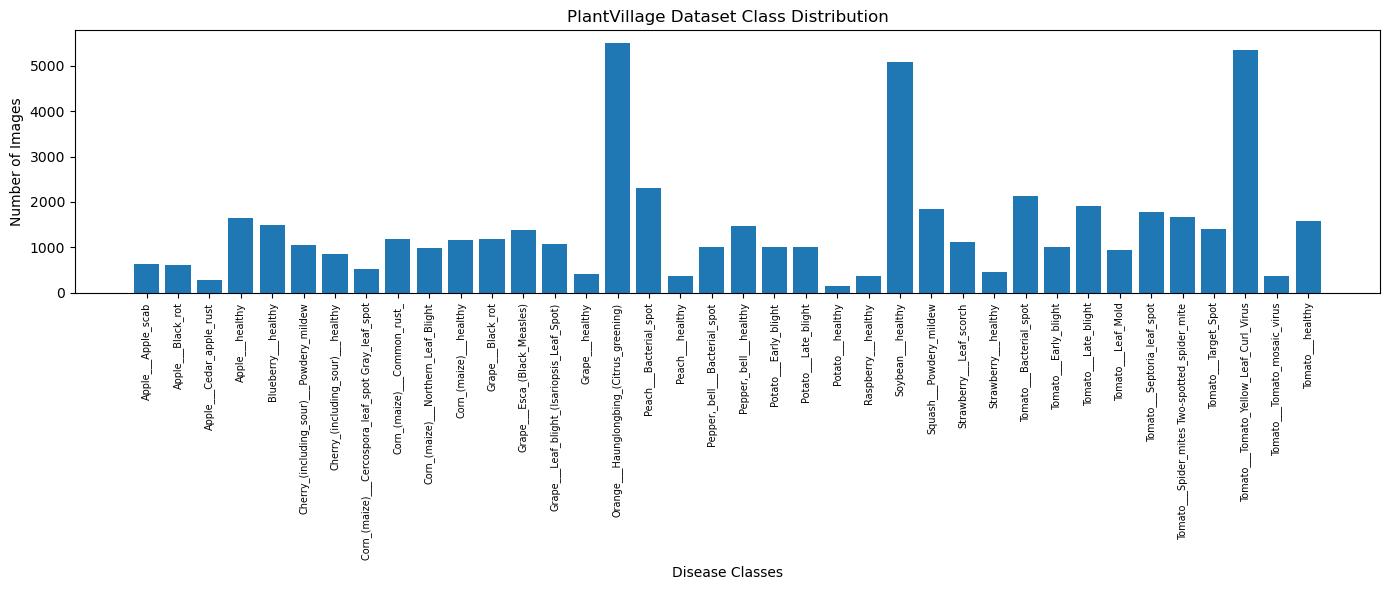

In [5]:
class_counts = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    class_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(14,6))
plt.bar(range(len(classes)), class_counts)

plt.title("PlantVillage Dataset Class Distribution")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")

plt.xticks(
    range(len(classes)),
    classes,
    rotation=90,
    fontsize=7
)

plt.tight_layout()
plt.show()

### Configure LBP Parameters

Configure the LBP descriptor used for texture feature extraction. The radius and number of neighbouring points determine the level of texture detail captured from leaf images.

In [6]:
radius = 1
n_points = 8
bins = n_points + 2

images_per_class = 200

### Image Preprocessing and Feature Extraction

This stage performs dataset validation, image preprocessing, and handcrafted feature extraction. Images are checked for corruption, resized to a uniform resolution, converted to grayscale for texture analysis, and processed using LBP and RGB colour histograms to generate feature vectors for SVM classification.

In [7]:
corrupt_count = 0
valid_count = 0 

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        img = cv2.imread(image_path)

        if img is None:
            corrupt_count += 1
            continue
        valid_count += 1
        img = cv2.resize(img, (128, 128))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        lbp = local_binary_pattern(
            gray,
            n_points,
            radius,
            method="uniform"
        )

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, n_points + 3),
            range=(0, n_points + 2)
        )

        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7)

        # RGB color histogram
        color_hist = []

        for channel in range(3):

            channel_hist = cv2.calcHist(
                [img],
                [channel],
                None,
                [32],
                [0, 256]
            )

            channel_hist = channel_hist.flatten()
            channel_hist = channel_hist / (channel_hist.sum() + 1e-7)
            color_hist.extend(channel_hist)

        feature_vector = np.hstack((hist, color_hist))

        X.append(feature_vector)
        y.append(class_to_label[class_name])  
        
          

In [8]:
print("\nDataset Integrity Check")
print("----------------------")
print("Valid images:", valid_count)
print("Corrupt images skipped:", corrupt_count)


Dataset Integrity Check
----------------------
Valid images: 54305
Corrupt images skipped: 0


### Feature Vector Visualization

The following plot illustrates an example feature vector generated from a single plant leaf image. The vector combines LBP texture descriptors and RGB colour histogram features, which are used as input to the SVM classifier.

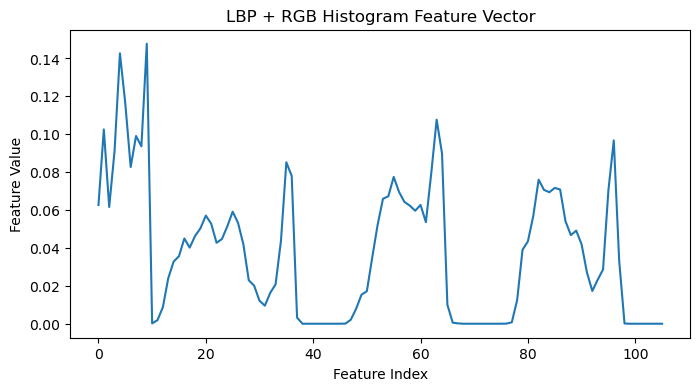

In [9]:
plt.figure(figsize=(8,4))
plt.plot(X[0])
plt.title("LBP + RGB Histogram Feature Vector")
plt.xlabel("Feature Index")
plt.ylabel("Feature Value")
plt.show()

### Feature Value Distribution

The histogram below shows the distribution of feature values extracted from a sample leaf image. This visualization helps understand how the LBP texture and RGB colour histogram features are distributed before classification.

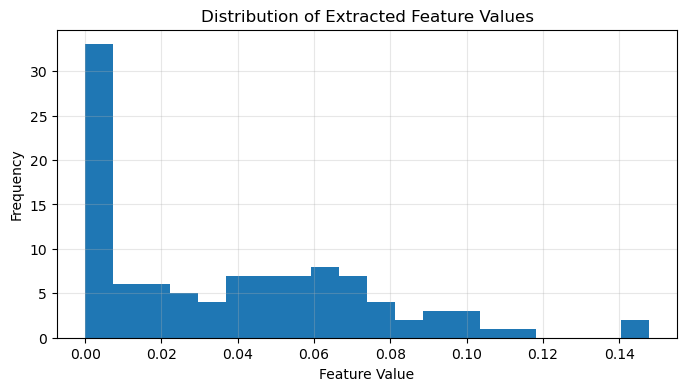

In [10]:
plt.figure(figsize=(8,4))
plt.hist(X[0], bins=20)
plt.title("Distribution of Extracted Feature Values")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.show()

### Dataset Summary

The dataset statistics below provide an overview of the extracted feature vectors, labels, and overall dataset size used for model training and evaluation.

In [11]:
print("Feature vectors:", len(X))
print("Labels:", len(y))
print("Feature length:", len(X[0]))

Feature vectors: 54305
Labels: 54305
Feature length: 106


### Convert Features to NumPy Arrays

In [12]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (54305, 106)
y shape: (54305,)


### Train-Test Split

In [13]:
# First split: 80% train+validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: create validation set from remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 34755
Validation samples: 8689
Testing samples: 10861


### Feature Scaling

Standardize extracted features before training the SVM model. Feature scaling helps ensure that all features contribute equally to the classification process and can improve SVM performance.

In [14]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### Hyperparameter Optimization Using Grid Search

To improve the performance of the SVM classifier, hyperparameter tuning was performed using GridSearchCV. A grid search approach was employed to systematically evaluate multiple combinations of the regularization parameter (C) and kernel coefficient (gamma) for the Radial Basis Function (RBF) kernel.


In [15]:
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': ['scale', 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

svm = grid.best_estimator_

Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.8873831103438355


### Train the Optimized SVM Classifier

The optimal hyperparameters identified through GridSearchCV were used to train the final SVM classifier. The selected configuration employed an RBF kernel with C = 10 and gamma = 0.01. The model was trained using the scaled feature vectors and subsequently evaluated on the test dataset.

In [16]:
svm = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01,
    random_state=42
)

svm.fit(X_train, y_train)

print("Optimized SVM training completed.")

Optimized SVM training completed.


### Training Accuracy Evaluation

Evaluate the optimized SVM classifier on the training dataset to measure how well the model fits the training data.

In [17]:
from sklearn.metrics import accuracy_score

train_pred = svm.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

print(f"SVM Train Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

SVM Train Accuracy: 0.9849 (98.49%)


### Validation Accuracy Evaluation

Evaluate the optimized SVM classifier on the validation dataset to measure generalization performance before final testing.



In [18]:
val_pred = svm.predict(X_val)

val_accuracy = accuracy_score(y_val, val_pred)

print(f"SVM Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

SVM Validation Accuracy: 0.9085 (90.85%)



### Model Prediction

Use the trained SVM model to predict plant disease classes for the unseen test dataset.

In [19]:
y_pred = svm.predict(X_test)

### Test Accuracy Evaluation

Measure the overall classification accuracy of the SVM model on the test dataset.

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print(f"SVM Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

SVM Test Accuracy: 0.9058 (90.58%)


### Accuracy Comparison

Compare the training, validation, and test accuracies of the optimized SVM model.

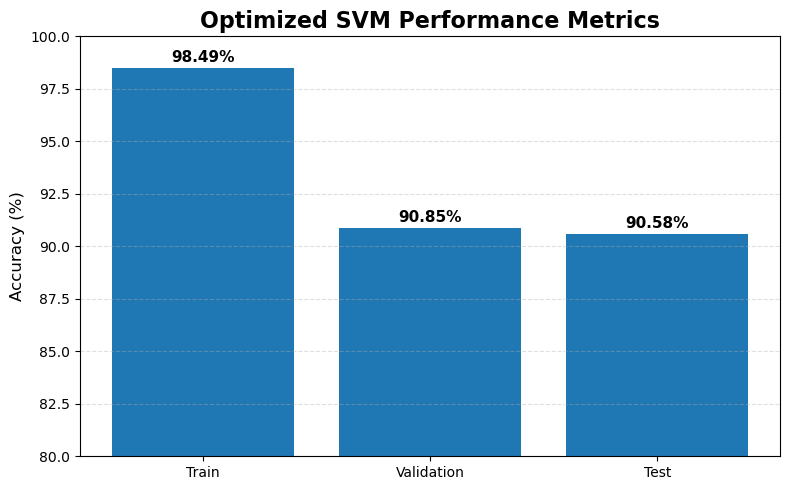

In [24]:
metrics = ['Train', 'Validation', 'Test']
scores = [
    train_accuracy * 100,
    val_accuracy * 100,
    accuracy * 100
]

plt.figure(figsize=(8,5))

bars = plt.bar(metrics, scores)

plt.title("Optimized SVM Performance Metrics", fontsize=16, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=12)

plt.ylim(80, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f'{height:.2f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Classification Report

Generate precision, recall, and F1-score metrics for each plant disease class to evaluate model performance in detail.

In [21]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df = report_df.reset_index()
report_df = report_df.rename(columns={"index": "Class"})

display(
    report_df.round(2).style.hide(axis="index")
)

Class,precision,recall,f1-score,support
0,0.820000,0.830000,0.830000,126.000000
1,0.870000,0.850000,0.860000,124.000000
2,0.730000,0.750000,0.740000,55.000000
3,0.880000,0.900000,0.890000,329.000000
4,0.900000,0.970000,0.930000,300.000000
5,0.880000,0.870000,0.880000,210.000000
6,0.960000,0.950000,0.960000,171.000000
7,0.710000,0.500000,0.580000,103.000000
8,1.000000,1.000000,1.000000,239.000000
9,0.700000,0.760000,0.730000,197.000000


### Confusion Matrix

Visualize the classification results across all disease classes. The confusion matrix helps identify correctly classified samples and common misclassification patterns.

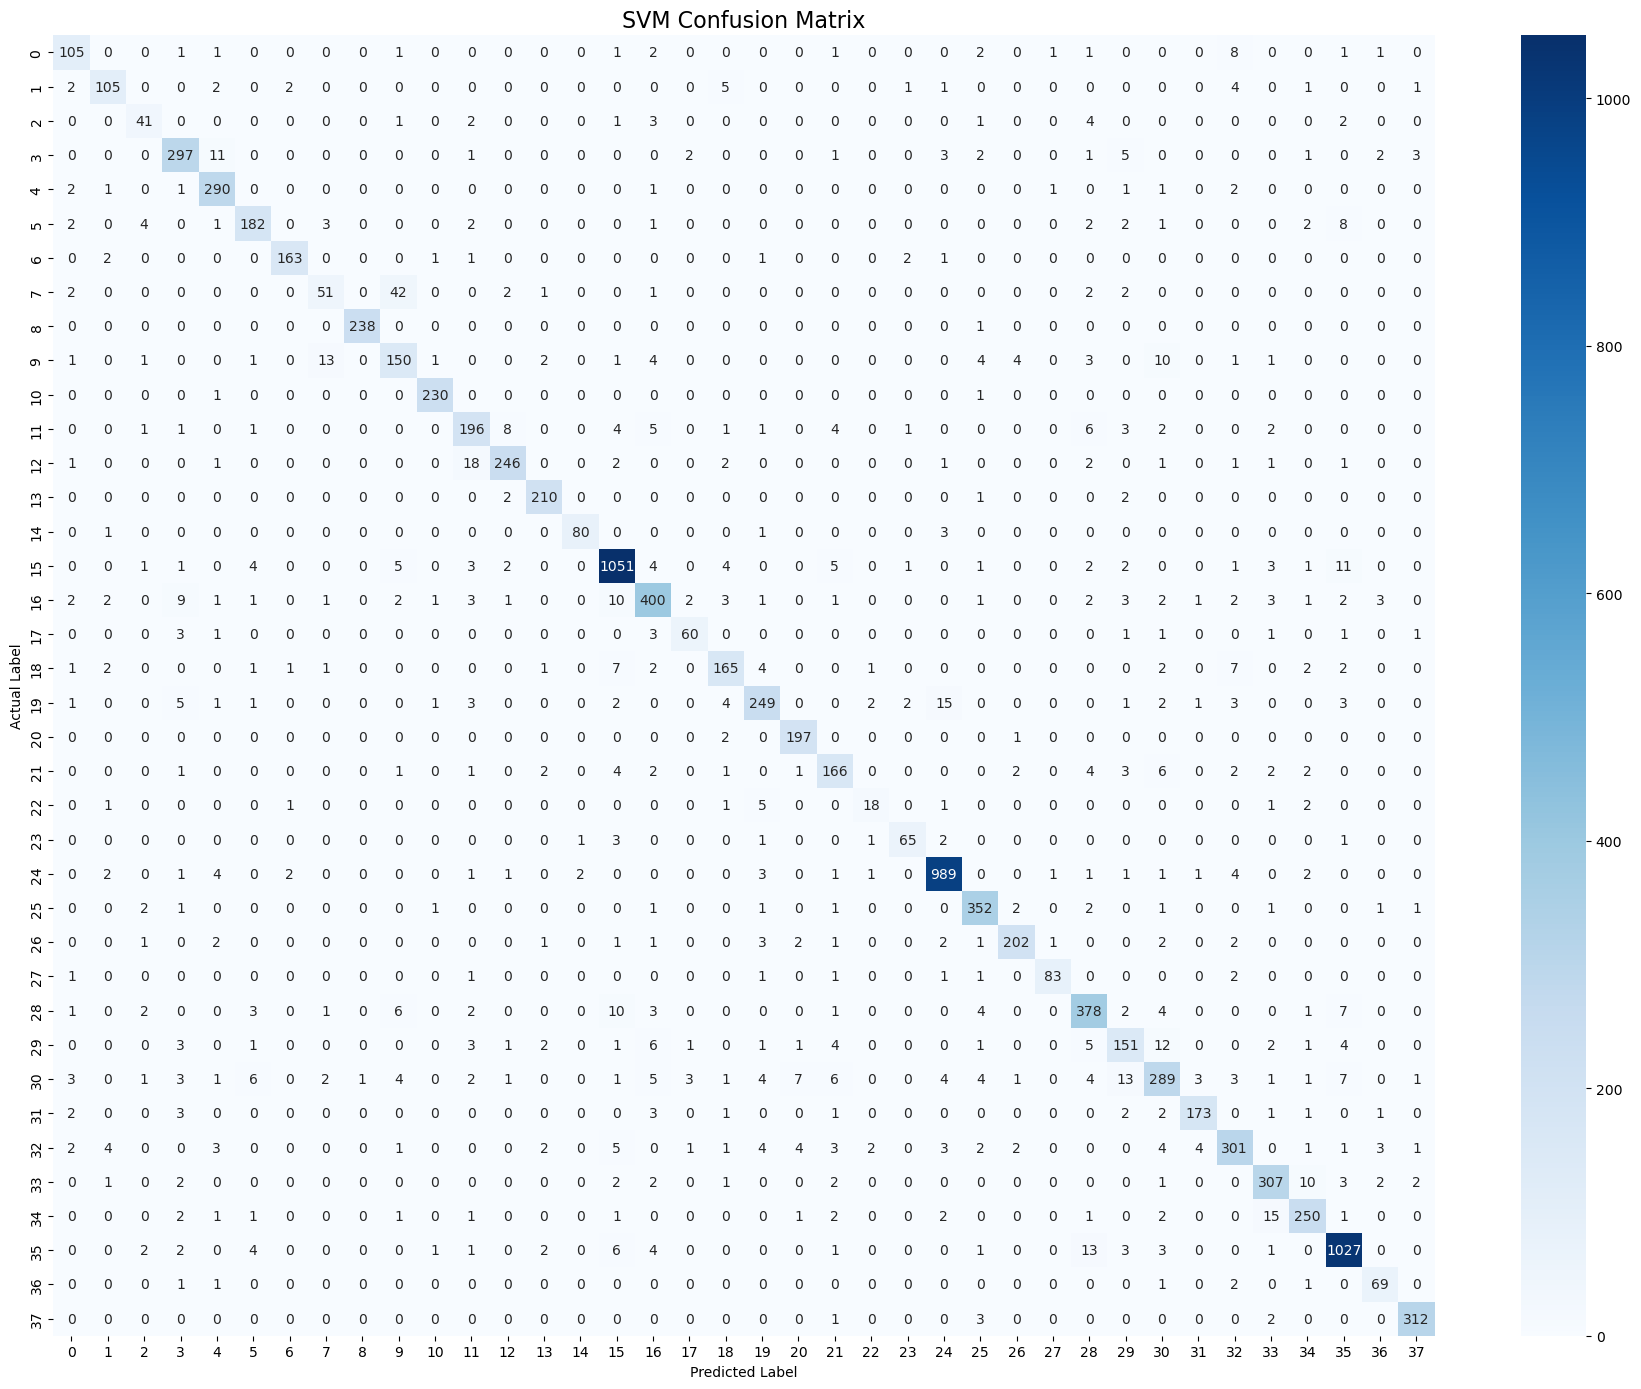

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True
)

plt.title("SVM Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()